# LSTM Model Training

### Importing Libraries

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.optimizers import Adam

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
import warnings
warnings.filterwarnings("ignore")

## Load Dataset

In [2]:
df = pd.read_csv("/content/all_bank_stock_data_clean.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.head()

,Date,Bank,Open,High,Low,Close,Volume,GBPUSD,Open_GBX,High_GBX,Low_GBX,Close_GBX
0,2015-01-02,Lloyds,76.103240,76.381896,75.306079,75.784775,54277932,1.557972,76.103240,76.381896,75.306079,75.784775
1,2015-01-02,Barclays,241.407284,244.796165,240.759418,242.354172,20219711,1.557972,241.407284,244.796165,240.759418,242.354172
2,2015-01-02,Goldman Sachs,155.581634,155.924179,153.510394,154.872635,1877700,1.557972,9986.163218,10008.149787,9853.218595,9940.655389
3,2015-01-05,Lloyds,75.705150,76.033569,74.102872,74.262108,102525515,1.528491,75.705150,76.033569,74.102872,74.262108
4,2015-01-05,Barclays,241.506939,242.354148,233.433445,233.931808,39050852,1.528491,241.506939,242.354148,233.433445,233.931808


## Per-Bank Scaling

In [3]:
bank_dates = {}
SEQUENCE_LENGTH = 60

bank_scalers = {}
bank_train_scaled = {}
bank_test_scaled = {}

for bank_name in sorted(df['Bank'].unique()):
    bank_df = df.loc[df['Bank'] == bank_name].sort_values('Date')
    bank_close = bank_df[['Close_GBX']]
    bank_dates[bank_name] = bank_df['Date'].values

    split_point = int(len(bank_close) * 0.8)
    train_close = bank_close.iloc[:split_point]
    test_close = bank_close.iloc[split_point:]

    scaler = MinMaxScaler()
    scaler.fit(train_close)

    bank_train_scaled[bank_name] = scaler.transform(train_close)
    bank_test_scaled[bank_name] = scaler.transform(test_close)
    bank_scalers[bank_name] = scaler

    print(f'{bank_name}: train={len(train_close)}  test={len(test_close)}')

Barclays: train=2352  test=589
Goldman Sachs: train=2341  test=586
Lloyds: train=2353  test=589


## Build Sequences

In [4]:
bank_sequences_train = {}
bank_sequences_test = {}
bank_test_dates = {}

for bank_name in bank_train_scaled:
    train_scaled = bank_train_scaled[bank_name]
    test_scaled = bank_test_scaled[bank_name]

    X_tr, y_tr = [], []
    for i in range(SEQUENCE_LENGTH, len(train_scaled)):
        X_tr.append(train_scaled[i - SEQUENCE_LENGTH:i, 0])
        y_tr.append(train_scaled[i, 0])

    full_scaled = np.concatenate([train_scaled, test_scaled])
    X_te, y_te = [], []
    for i in range(len(train_scaled), len(full_scaled)):
        X_te.append(full_scaled[i - SEQUENCE_LENGTH:i, 0])
        y_te.append(full_scaled[i, 0])

    bank_sequences_train[bank_name] = (np.array(X_tr), np.array(y_tr))
    bank_sequences_test[bank_name] = (np.array(X_te), np.array(y_te))
    n_train = len(bank_train_scaled[bank_name])
    bank_test_dates[bank_name] = bank_dates[bank_name][n_train:n_train + len(y_te)]

## Pool All Three Banks Into One Training Set

In [5]:
X_train_parts, X_test_parts = [], []
y_train_parts, y_test_parts = [], []
test_bank_names = []
test_dates_parts = []

for bank_name in bank_sequences_train:
    X_tr, y_tr = bank_sequences_train[bank_name]
    X_te, y_te = bank_sequences_test[bank_name]

    X_train_parts.append(X_tr)
    X_test_parts.append(X_te)
    y_train_parts.append(y_tr)
    y_test_parts.append(y_te)

    test_bank_names.extend([bank_name] * len(X_te))
    test_dates_parts.append(bank_test_dates[bank_name])

X_train = np.concatenate(X_train_parts).reshape(-1, SEQUENCE_LENGTH, 1)
X_test = np.concatenate(X_test_parts).reshape(-1, SEQUENCE_LENGTH, 1)

y_train = np.concatenate(y_train_parts)
y_test = np.concatenate(y_test_parts)

test_dates_pooled = np.concatenate(test_dates_parts)
test_bank_names = np.array(test_bank_names)
print('X_train:', X_train.shape, ' X_test:', X_test.shape)

X_train: (6866, 60, 1)  X_test: (1764, 60, 1)


## Hyperparameter Tuning

In [6]:
val_split = int(len(X_train) * 0.85)
X_tr, X_val = X_train[:val_split], X_train[val_split:]
y_tr, y_val = y_train[:val_split], y_train[val_split:]

lstm_configs = [
    {'units': 32,  'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001},
    {'units': 64,  'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001},
    {'units': 64,  'dropout': 0.3, 'batch_size': 16, 'learning_rate': 0.0005},
    {'units': 100, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001},
]

def build_lstm(units, dropout, learning_rate):
    m = Sequential()
    m.add(LSTM(units, return_sequences=True, input_shape=(SEQUENCE_LENGTH, 1)))
    m.add(Dropout(dropout))
    m.add(LSTM(units))
    m.add(Dropout(dropout))
    m.add(Dense(1))
    m.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse')
    return m

tuning_start_time = time.time()

tuning_results = []

for cfg in lstm_configs:
    tuning_model = build_lstm(cfg['units'], cfg['dropout'], cfg['learning_rate'])

    tuning_history = tuning_model.fit(
        X_tr, y_tr,
        epochs=15,
        batch_size=cfg['batch_size'],
        validation_data=(X_val, y_val),
        verbose=0,
    )

    val_loss = min(tuning_history.history['val_loss'])
    tuning_results.append({**cfg, 'val_loss': val_loss})
    print(cfg, '-> val_loss:', val_loss)

tuning_time = time.time() - tuning_start_time
print(f'Hyperparameter search time: {tuning_time:.1f}s')

tuning_df = pd.DataFrame(tuning_results).sort_values('val_loss').reset_index(drop=True)
tuning_df

{'units': 32, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001} -> val_loss: 0.00044826537487097085
{'units': 64, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001} -> val_loss: 0.0003279541269876063
{'units': 64, 'dropout': 0.3, 'batch_size': 16, 'learning_rate': 0.0005} -> val_loss: 0.0003553422284312546
{'units': 100, 'dropout': 0.2, 'batch_size': 32, 'learning_rate': 0.001} -> val_loss: 0.00029215693939477205
Hyperparameter search time: 1116.9s


,units,dropout,batch_size,learning_rate,val_loss
0,100,0.2,32,0.0010,0.000292
1,64,0.2,32,0.0010,0.000328
2,64,0.3,16,0.0005,0.000355
3,32,0.2,32,0.0010,0.000448


## Train Final Model

In [7]:
from tensorflow.keras.callbacks import EarlyStopping

best_config = tuning_df.iloc[0].to_dict()
print('Best LSTM config:', best_config)

model = build_lstm(
    int(best_config['units']),
    best_config['dropout'],
    best_config['learning_rate'],
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
)

fit_start_time = time.time()
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=int(best_config['batch_size']),
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1,
)
fit_time = time.time() - fit_start_time
training_time = tuning_time + fit_time
print(f'Stopped after {len(history.history["loss"])} epochs.')
print(f'Final model fit time: {fit_time:.1f}s   Total (tuning + fit): {training_time:.1f}s')

Best LSTM config: {'units': 100.0, 'dropout': 0.2, 'batch_size': 32.0, 'learning_rate': 0.001, 'val_loss': 0.00029215693939477205}
Epoch 1/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 28s 112ms/step - loss: 0.0063 - val_loss: 9.5617e-04
Epoch 2/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 113ms/step - loss: 0.0019 - val_loss: 5.6047e-04
Epoch 3/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 24s 109ms/step - loss: 0.0017 - val_loss: 7.1023e-04
Epoch 4/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 23s 108ms/step - loss: 0.0015 - val_loss: 4.8431e-04
Epoch 5/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 42s 115ms/step - loss: 0.0014 - val_loss: 4.6063e-04
Epoch 6/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 41s 116ms/step - loss: 0.0013 - val_loss: 3.8719e-04
Epoch 7/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 22s 102ms/step - loss: 0.0012 - val_loss: 3.9550e-04
Epoch 8/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 43s 109ms/step - loss: 0.0012 - val_loss: 5.2536e-04
Epoch 9/100
215/215 ━━━━━━━━━━━━━━━━━━━━ 23s 105ms/step - loss: 0.0011 - val_loss: 3.6527e-04
Epoch 10/100
215/215 ━━

## Predict and Inverse-Transform

In [8]:
pred_scaled = model.predict(X_test)

pred_parts, actual_parts, bank_parts = [], [], []

for bank_name in sorted(set(test_bank_names)):
    mask = test_bank_names == bank_name
    scaler = bank_scalers[bank_name]

    pred_parts.append(scaler.inverse_transform(pred_scaled[mask]))
    actual_parts.append(scaler.inverse_transform(y_test[mask].reshape(-1, 1)))
    bank_parts.append(np.full(mask.sum(), bank_name))

lstm_pred = np.concatenate(pred_parts).flatten()
actual = np.concatenate(actual_parts).flatten()
test_bank_labels = np.concatenate(bank_parts)

56/56 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step


## Evaluation (Pooled, All Three Banks)

In [9]:
def evaluate(actual_vals, predicted_vals):
    mae = mean_absolute_error(actual_vals, predicted_vals)
    rmse = np.sqrt(mean_squared_error(actual_vals, predicted_vals))
    mape = np.mean(np.abs((actual_vals - predicted_vals) / actual_vals)) * 100
    r2 = r2_score(actual_vals, predicted_vals)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

pooled_metrics = evaluate(actual, lstm_pred)
print('Pooled (all 3 banks, mixed currency scale):')
for k, v in pooled_metrics.items():
    print(f'  {k}: {v:.4f}')

Pooled (all 3 banks, mixed currency scale):
  MAE: 1127.7644
  RMSE: 2529.5060
  MAPE: 3.6266
  R2: 0.9905


### Per-Bank Breakdown

In [10]:
per_bank_results = []

for bank_name in np.unique(test_bank_labels):
    mask = test_bank_labels == bank_name
    m = evaluate(actual[mask], lstm_pred[mask])
    m['Bank'] = bank_name
    per_bank_results.append(m)

per_bank_df = pd.DataFrame(per_bank_results)[['Bank', 'MAE', 'RMSE', 'MAPE', 'R2']]
per_bank_df

,Bank,MAE,RMSE,MAPE,R2
0,Barclays,12.862414,16.892997,3.310844,0.970723
1,Goldman Sachs,3380.274866,4388.669831,5.665277,0.905477
2,Lloyds,1.628753,2.188866,1.914068,0.987467


## Actual vs Predicted

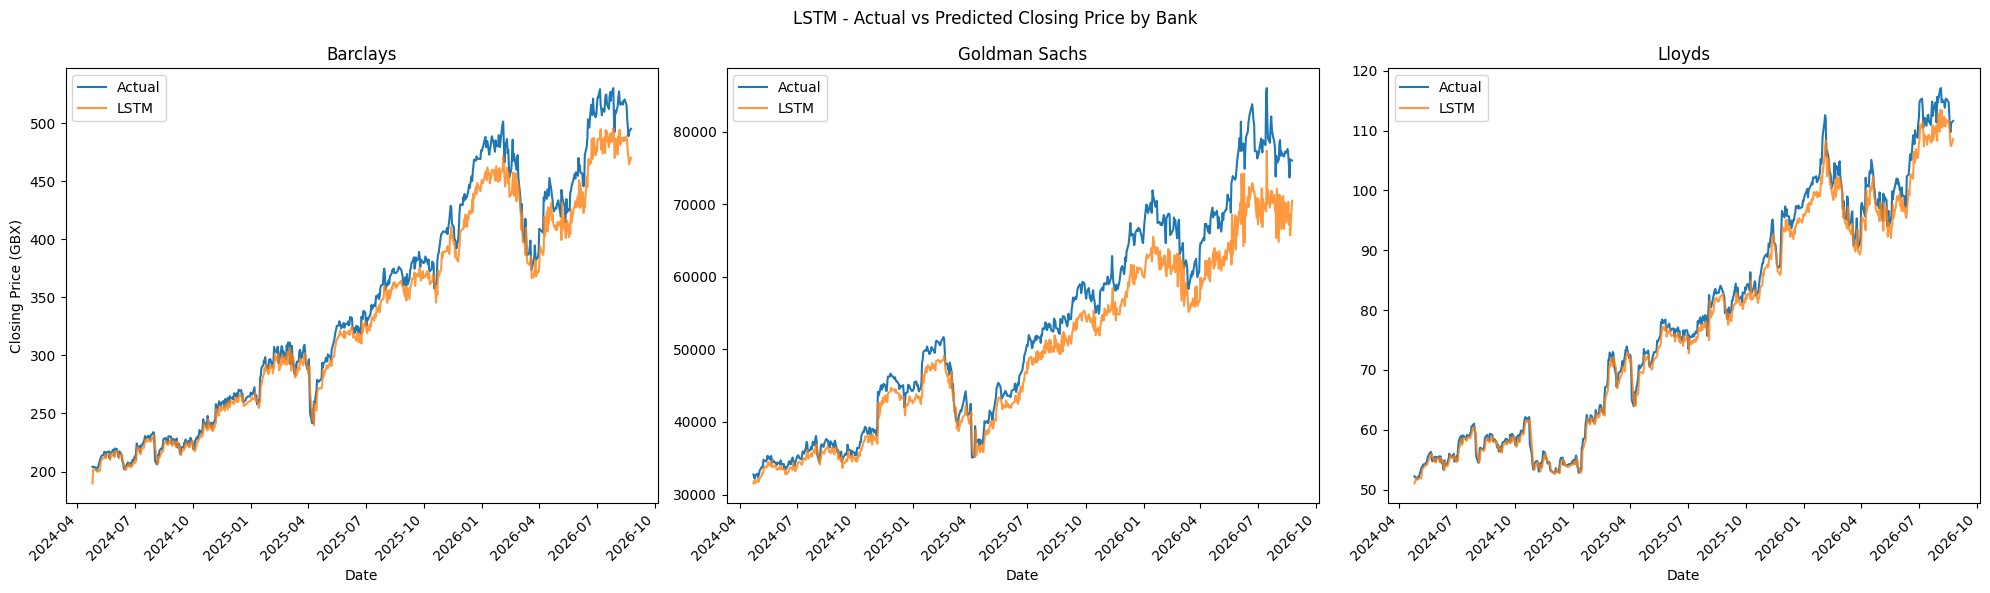

In [11]:
# Split into one panel per bank, each with real dates and its own y-axis scale,
# instead of one pooled chart - see Random_Forest_model.ipynb for the same fix
# and why it's needed (pooling banks with very different price levels squashes
# Lloyds/Barclays to an invisible flat line next to Goldman Sachs).
assert len(test_dates_pooled) == len(actual), 'dates/predictions length mismatch - check bank ordering'

banks_in_order = np.unique(test_bank_labels)
fig, axes = plt.subplots(1, len(banks_in_order), figsize=(20, 6))

for ax, bank_name in zip(axes, banks_in_order):
    mask = test_bank_labels == bank_name
    ax.plot(test_dates_pooled[mask], actual[mask], label='Actual')
    ax.plot(test_dates_pooled[mask], lstm_pred[mask], label='LSTM', alpha=0.8)
    ax.set_title(bank_name)
    ax.set_xlabel('Date')
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')
    ax.legend()

axes[0].set_ylabel('Closing Price (GBX)')
fig.suptitle('LSTM - Actual vs Predicted Closing Price by Bank')
plt.tight_layout()
plt.show()


## Training vs Validation Loss

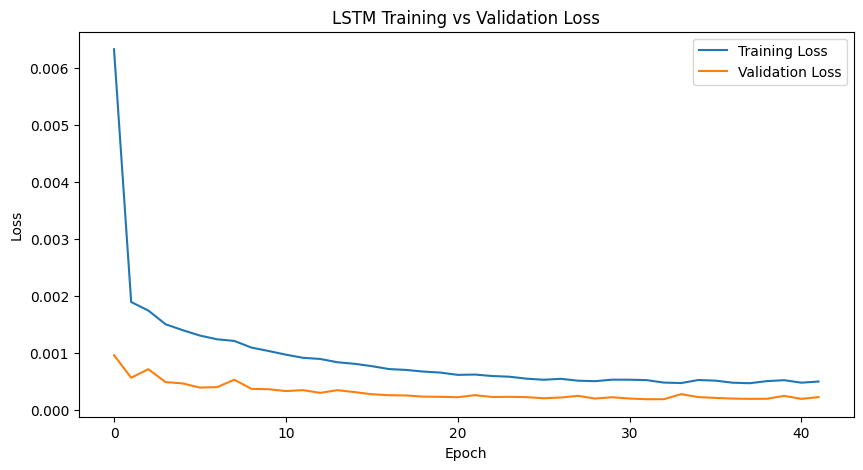

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Prediction Error Distribution

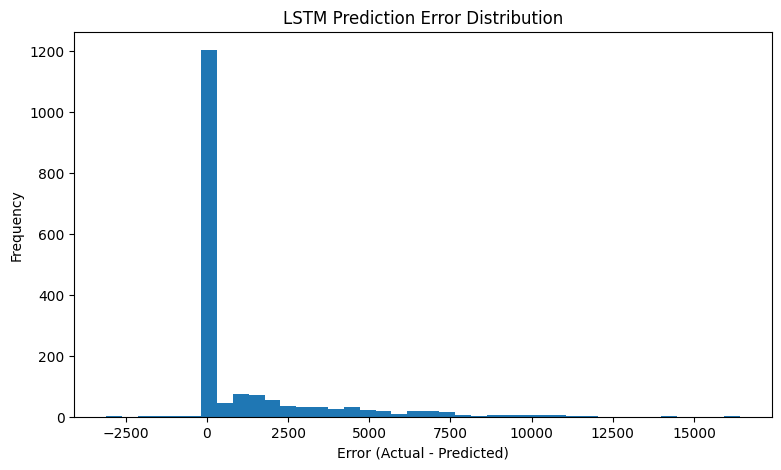

In [13]:
errors = actual - lstm_pred
plt.figure(figsize=(9, 5))
plt.hist(errors, bins=40)
plt.title('LSTM Prediction Error Distribution')
plt.xlabel('Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

## Save Results

In [14]:
summary_rows = [{'Bank': 'All (pooled)', 'Model': 'LSTM',
                 'Training_Time_Sec': training_time, **pooled_metrics}]

for row in per_bank_results:
    summary_rows.append({'Bank': row['Bank'], 'Model': 'LSTM',
                          'Training_Time_Sec': None,
                          'MAE': row['MAE'], 'RMSE': row['RMSE'],
                          'MAPE': row['MAPE'], 'R2': row['R2']})

lstm_results_summary = pd.DataFrame(summary_rows)
lstm_results_summary.to_csv('lstm_results_summary.csv', index=False)
print('Saved lstm_results_summary.csv')
lstm_results_summary

Saved lstm_results_summary.csv


,Bank,Model,Training_Time_Sec,MAE,RMSE,MAPE,R2
0,All (pooled),LSTM,2424.692313,1127.764382,2529.506006,3.626602,0.990541
1,Barclays,LSTM,NaN,12.862414,16.892997,3.310844,0.970723
2,Goldman Sachs,LSTM,NaN,3380.274866,4388.669831,5.665277,0.905477
3,Lloyds,LSTM,NaN,1.628753,2.188866,1.914068,0.987467
